# Predicción de precios de acciones: entrenamiento de un agente

## Victor Cen

## Descripción
En esta práctica se implementa un agente sencillo para la toma de decisiones en el mercado bursátil utilizando precios históricos de acciones actualizados. El objetivo es demostrar que el ejercicio propuesto sigue siendo funcional con datos recientes, además de analizar los resultados obtenidos y documentar claramente las modificaciones realizadas al código original.

## ¿De qué trata esta actividad?

Esta actividad trata de modelar el problema de compra y venta de acciones como un proceso de toma de decisiones secuencial. Un agente observa un estado compuesto por el presupuesto disponible, el número actual de acciones y un historial reciente de precios. Con base en ello, puede tomar una de tres acciones posibles:

- Comprar
- Vender
- Mantener

El propósito de esta práctica no es construir una estrategia financiera real, sino comprender cómo representar este problema computacionalmente, cómo simular el comportamiento del agente y cómo evaluar sus resultados.

## Fundamento teórico

De acuerdo con el material proporcionado, el estado del agente se construye a partir de:

- presupuesto actual,
- número actual de acciones,
- historial reciente de precios.

En el ejemplo del documento, se utilizan 200 precios históricos, más 2 variables adicionales, por lo que cada estado tiene 202 dimensiones.

La política del agente determina qué acción debe realizar en cada estado. Para comenzar, se utiliza una política aleatoria, que selecciona acciones sin analizar realmente el estado. Esto sirve como línea base antes de usar políticas más avanzadas.

In [4]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
from datetime import date

In [29]:
def get_prices(ticker_symbol="MSFT", start_date="2015-01-01", end_date=None):
    """
    Descarga precios históricos de apertura de una acción.
    
    Parámetros:
        ticker_symbol (str): símbolo bursátil, por ejemplo 'MSFT'
        start_date (str): fecha de inicio en formato YYYY-MM-DD
        end_date (str): fecha final en formato YYYY-MM-DD
    
    Retorna:
        prices (np.array): arreglo 1D con precios de apertura
        data (pd.DataFrame): dataframe completo
    """
    if end_date is None:
        end_date = date.today().strftime("%Y-%m-%d")
    
    data = yf.download(
        ticker_symbol,
        start=start_date,
        end=end_date,
        auto_adjust=False,
        progress=False
    )
    
    if data.empty:
        raise ValueError("No se descargaron datos. Verifica el ticker o la conexión.")
    
    # Aseguramos que sea vector de una dimensión
    prices = data["Open"].dropna().to_numpy().reshape(-1).astype(float)
    
    return prices, data

In [31]:
ticker = "MSFT"
prices, df_prices = get_prices(ticker_symbol=ticker, start_date="2015-01-01")

print("Número de registros descargados:", len(prices))
df_prices.head()

Número de registros descargados: 2812


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,MSFT,MSFT,MSFT,MSFT,MSFT,MSFT
Date,,,,,,
2015-01-02,39.767685,46.759998,47.419998,46.540001,46.660000,27913900
2015-01-05,39.401981,46.330002,46.730000,46.250000,46.369999,39673900
2015-01-06,38.823681,45.650002,46.750000,45.540001,46.380001,36447900
2015-01-07,39.316940,46.230000,46.459999,45.490002,45.980000,29114100
2015-01-08,40.473572,47.590000,47.750000,46.720001,46.750000,29645200


In [33]:
print("Tipo de prices:", type(prices))
print("Shape de prices:", prices.shape)
print("Primeros 5 valores:", prices[:5])

Tipo de prices: <class 'numpy.ndarray'>
Shape de prices: (2812,)
Primeros 5 valores: [46.65999985 46.36999893 46.38000107 45.97999954 46.75      ]


## Obtención de datos actualizados

En esta sección se descargan los precios históricos de apertura de la acción de Microsoft (`MSFT`) usando datos actualizados hasta la fecha actual.

Esto permite cumplir con la consigna de demostrar que el ejercicio sigue siendo funcional utilizando información reciente del mercado.

In [35]:
def plot_prices(prices, ticker="MSFT"):
    plt.figure(figsize=(12, 6))
    plt.plot(prices)
    plt.title(f"Precios de apertura de {ticker}")
    plt.xlabel("Día")
    plt.ylabel("Precio ($)")
    plt.grid(True, alpha=0.3)
    plt.show()

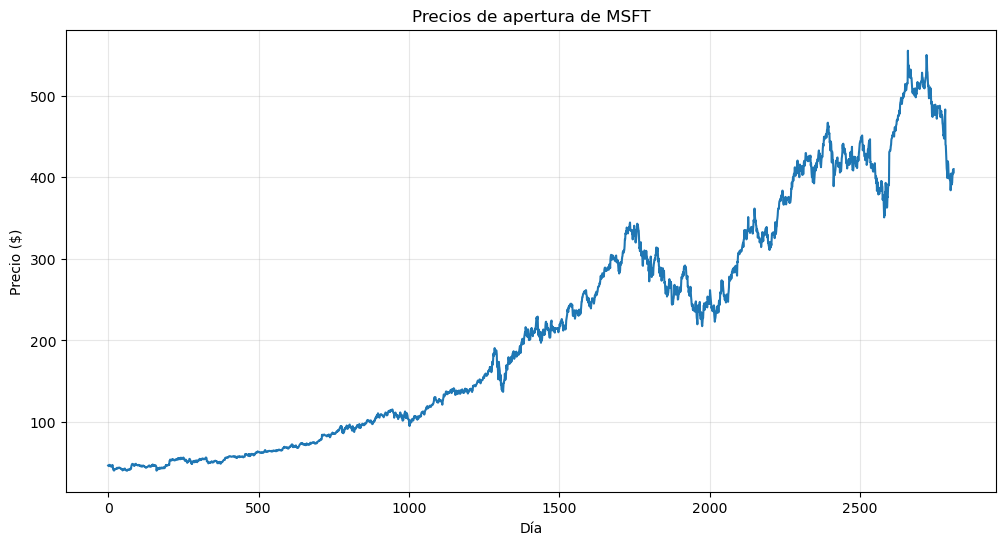

In [39]:
plot_prices(prices, ticker=ticker)

## Análisis de la gráfica de precios

La gráfica muestra la evolución histórica del precio de apertura de la acción seleccionada. Se puede observar que el comportamiento del precio cambia a lo largo del tiempo, con periodos de crecimiento, caídas y fluctuaciones.

Esto es importante porque el agente debe tomar decisiones en un entorno variable, donde no existe una tendencia perfectamente estable. Por ello, el problema resulta adecuado para simularse como una secuencia de decisiones dependientes del estado actual del mercado.

In [16]:
class DecisionPolicy:
    def select_action(self, current_state, step):
        raise NotImplementedError("Esta función debe implementarse en una subclase")
    
    def update_q(self, state, action, reward, next_state):
        pass

## Clase base de política

Se define una clase base llamada `DecisionPolicy`, que representa la estructura general de una política de decisión. Esta clase servirá como punto de partida para implementar distintas estrategias.

La función `select_action()` se encargará de decidir qué acción tomar. La función `update_q()` se deja preparada para futuras versiones donde el agente pueda aprender de la experiencia.

In [19]:
class RandomDecisionPolicy(DecisionPolicy):
    def __init__(self, actions):
        self.actions = actions
        
    def select_action(self, current_state, step):
        return random.choice(self.actions)

In [21]:
actions = ["Buy", "Sell", "Hold"]
policy = RandomDecisionPolicy(actions)

print("Acción de ejemplo:", policy.select_action(None, 0))

Acción de ejemplo: Hold


## Política aleatoria

La primera política implementada es una política aleatoria. Esto significa que el agente selecciona entre comprar, vender o mantener sin analizar realmente el estado.

Aunque esta estrategia no es inteligente, sí permite probar que la simulación funciona correctamente y sirve como punto de comparación para métodos más avanzados.

In [41]:
def run_simulation(policy, initial_budget, initial_num_stocks, prices, hist, debug=False):
    # Aseguramos que prices sea un vector 1D
    prices = np.asarray(prices).reshape(-1).astype(float)
    
    budget = float(initial_budget)
    num_stocks = int(initial_num_stocks)
    share_value = 0.0
    
    # Validación por si hist es demasiado grande
    if len(prices) <= hist + 1:
        raise ValueError("No hay suficientes datos para el tamaño de historial seleccionado.")
    
    for i in range(len(prices) - hist - 1):
        current_state = np.hstack((prices[i:i+hist], [budget, num_stocks]))
        current_portfolio = budget + num_stocks * prices[i + hist]
        
        action = policy.select_action(current_state, i)
        share_value = float(prices[i + hist])
        
        if action == "Buy" and budget >= share_value:
            budget -= share_value
            num_stocks += 1
            
        elif action == "Sell" and num_stocks > 0:
            budget += share_value
            num_stocks -= 1
            
        else:
            action = "Hold"
        
        new_portfolio = budget + num_stocks * share_value
        reward = new_portfolio - current_portfolio
        
        next_state = np.hstack((prices[i+1:i+1+hist], [budget, num_stocks]))
        
        policy.update_q(current_state, action, reward, next_state)
        
        if debug and i % 200 == 0:
            print(
                f"Paso {i} | Acción: {action} | "
                f"Presupuesto: {budget:.2f} | "
                f"Acciones: {num_stocks} | "
                f"Portafolio: {new_portfolio:.2f}"
            )
    
    final_portfolio = budget + num_stocks * share_value
    return final_portfolio

## Simulación del agente

La simulación recorre los precios históricos y en cada paso:

1. construye el estado actual,
2. la política selecciona una acción,
3. se actualiza el presupuesto y el número de acciones,
4. se calcula el nuevo valor del portafolio,
5. y se obtiene una recompensa.

La recompensa se define como la diferencia entre el nuevo valor del portafolio y el valor anterior. Esto permite medir si la acción realizada benefició o perjudicó al agente.

In [43]:
hist = 200
budget = 1000.0
num_stocks = 0

final_portfolio = run_simulation(
    policy=policy,
    initial_budget=budget,
    initial_num_stocks=num_stocks,
    prices=prices,
    hist=hist,
    debug=True
)

print(f"Valor final del portafolio: {final_portfolio:.2f}")

Paso 0 | Acción: Hold | Presupuesto: 1000.00 | Acciones: 0 | Portafolio: 1000.00
Paso 200 | Acción: Sell | Presupuesto: 976.00 | Acciones: 0 | Portafolio: 976.00
Paso 400 | Acción: Sell | Presupuesto: 861.32 | Acciones: 2 | Portafolio: 997.10
Paso 600 | Acción: Hold | Presupuesto: 258.26 | Acciones: 10 | Portafolio: 1200.96
Paso 800 | Acción: Buy | Presupuesto: 985.81 | Acciones: 3 | Portafolio: 1290.70
Paso 1000 | Acción: Sell | Presupuesto: 711.38 | Acciones: 6 | Portafolio: 1536.14
Paso 1200 | Acción: Buy | Presupuesto: 331.60 | Acciones: 8 | Portafolio: 1943.36
Paso 1400 | Acción: Hold | Presupuesto: 553.53 | Acciones: 7 | Portafolio: 2248.72
Paso 1600 | Acción: Hold | Presupuesto: 170.03 | Acciones: 8 | Portafolio: 2531.15
Paso 1800 | Acción: Hold | Presupuesto: 597.67 | Acciones: 6 | Portafolio: 2082.37
Paso 2000 | Acción: Sell | Presupuesto: 1453.44 | Acciones: 3 | Portafolio: 2406.69
Paso 2200 | Acción: Hold | Presupuesto: 3025.96 | Acciones: 0 | Portafolio: 3025.96
Paso 2400 |

## Primera ejecución

Con esta primera simulación se observa el comportamiento del agente durante una corrida completa. Sin embargo, como la política es aleatoria, una sola ejecución no es suficiente para evaluar su desempeño real.

Por ello, es necesario repetir el experimento varias veces y calcular estadísticas como el promedio y la desviación estándar.

In [46]:
def run_simulations(policy, budget, num_stocks, prices, hist, num_tries=100):
    final_portfolios = []
    
    for _ in range(num_tries):
        final_portfolio = run_simulation(
            policy=policy,
            initial_budget=budget,
            initial_num_stocks=num_stocks,
            prices=prices,
            hist=hist,
            debug=False
        )
        final_portfolios.append(final_portfolio)
    
    avg = np.mean(final_portfolios)
    std = np.std(final_portfolios)
    
    return avg, std, final_portfolios

In [48]:
avg, std, portfolios = run_simulations(
    policy=policy,
    budget=budget,
    num_stocks=num_stocks,
    prices=prices,
    hist=hist,
    num_tries=100
)

print(f"Promedio del portafolio final: {avg:.2f}")
print(f"Desviación estándar: {std:.2f}")

Promedio del portafolio final: 2875.42
Desviación estándar: 712.41


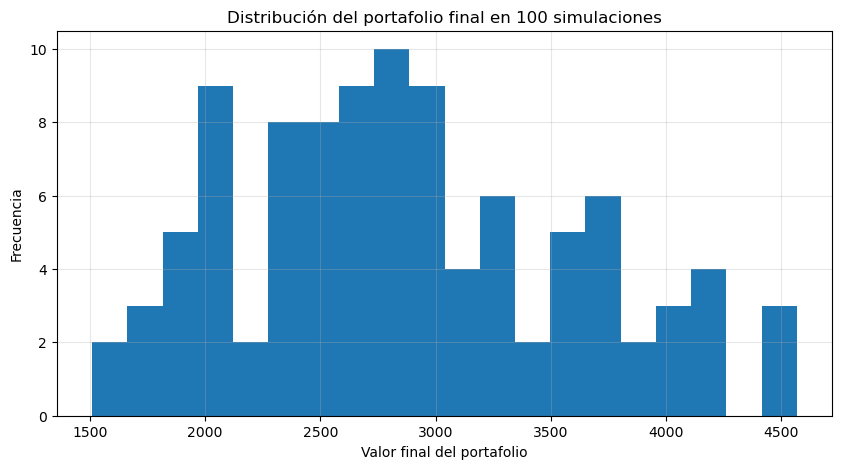

In [50]:
plt.figure(figsize=(10, 5))
plt.hist(portfolios, bins=20)
plt.title("Distribución del portafolio final en 100 simulaciones")
plt.xlabel("Valor final del portafolio")
plt.ylabel("Frecuencia")
plt.grid(True, alpha=0.3)
plt.show()

In [52]:
profit = avg - budget

print(f"Capital inicial: {budget:.2f}")
print(f"Promedio final del portafolio: {avg:.2f}")
print(f"Ganancia/Pérdida promedio: {profit:.2f}")

Capital inicial: 1000.00
Promedio final del portafolio: 2875.42
Ganancia/Pérdida promedio: 1875.42


## Análisis de resultados

Los resultados obtenidos muestran que la política aleatoria genera un comportamiento variable entre ejecuciones. Esto sucede porque el agente no aprende del mercado ni utiliza una estrategia basada en patrones, sino que selecciona acciones al azar.

El valor promedio del portafolio final permite observar el desempeño general del agente después de múltiples simulaciones. Si dicho promedio se mantiene cercano al capital inicial, se puede concluir que la política aleatoria no aporta una mejora significativa. Por otra parte, una desviación estándar elevada indica que existe una gran dispersión entre los resultados, lo cual confirma que el comportamiento depende del azar.

Desde mi análisis, esta política sí es útil como punto de partida, porque permite comprobar que el entorno de simulación funciona correctamente con datos actualizados. Sin embargo, no es suficiente para representar una estrategia real de inversión. Para mejorar el desempeño del agente sería necesario implementar una política que aprenda de las recompensas obtenidas, como Q-Learning o Deep Q-Learning.

También se observa que el comportamiento del portafolio depende del movimiento histórico del precio de la acción. Si existen cambios bruscos en el mercado, la política aleatoria puede producir tanto ganancias como pérdidas sin consistencia.

## Cambio 1: actualización de la librería y estructura de precios

### Código original
```python
from yahoo_finance import Share

def get_prices(share_symbol, start_date, end_date, cache_filename):
    try:
        stock_prices = np.load(cache_filename)
    except IOError:
        share = Share(share_symbol)
        stock_hist = share.get_historical(start_date, end_date)
        stock_prices = [stock_price['Open'] for stock_price in stock_hist]
        np.save(cache_filename, stock_prices)
    return stock_prices
```

### Código modificado
```python
def get_prices(ticker_symbol="MSFT", start_date="2015-01-01", end_date=None):
    if end_date is None:
        end_date = date.today().strftime("%Y-%m-%d")
    
    data = yf.download(
        ticker_symbol,
        start=start_date,
        end=end_date,
        auto_adjust=False,
        progress=False
    )
    
    if data.empty:
        raise ValueError("No se descargaron datos. Verifica el ticker o la conexión.")
    
    prices = data["Open"].dropna().to_numpy().reshape(-1).astype(float)
    
    return prices, data
```

### Justificación
Se reemplazó la librería original por `yfinance` para trabajar con datos históricos actualizados. Además, se aseguró que el arreglo de precios quedara en una sola dimensión, ya que esto es necesario para construir correctamente el estado del agente dentro de la simulación.

## Cambio 2: actualización del rango de fechas

### Código original
```python
prices = get_prices('MSFT', '2000-07-01', '2017-07-01', 'historical_stock_prices.npy')
```

### Código modificado
```python
ticker = "MSFT"
prices, df_prices = get_prices(ticker_symbol=ticker, start_date="2015-01-01")
```

### Justificación
Se actualizó el rango temporal para utilizar datos recientes hasta la fecha actual, tal como lo solicita la actividad. De esta forma se demuestra que el ejercicio sigue siendo funcional con información actualizada.

## Cambio 3: ajuste en la simulación para evitar errores de dimensiones

### Código original
```python
current_state = np.hstack((prices[i:i+hist], budget, num_stocks))
next_state = np.hstack((prices[i+1:i+1+hist], budget, num_stocks))
```

### Código modificado
```python
current_state = np.hstack((prices[i:i+hist], [budget, num_stocks]))
next_state = np.hstack((prices[i+1:i+1+hist], [budget, num_stocks]))
```

### Justificación
Se ajustó la forma de concatenar los datos del estado para evitar errores de dimensiones en `numpy`. Al agrupar `budget` y `num_stocks` dentro de una lista, ambos valores se integran correctamente al vector del estado.

## Comentario sobre las modificaciones

Los cambios realizados no alteran la lógica principal del ejercicio. Su propósito fue adaptar el código para que pudiera ejecutarse correctamente con datos actuales, mejorar la claridad del notebook y documentar de forma ordenada cada modificación.

# Conclusiones

En esta práctica se implementó un agente sencillo para simular decisiones de compra, venta o mantenimiento de acciones utilizando precios históricos actualizados.

Se comprobó que el ejercicio sigue siendo funcional con datos recientes, lo cual cumple con uno de los objetivos principales de la actividad. Además, se observó que una política aleatoria produce resultados muy variables, por lo que no constituye una estrategia de inversión confiable.

Aun así, este modelo resulta útil como punto de partida para comprender cómo se define el estado, cómo se seleccionan acciones y cómo se calcula la recompensa dentro de un entorno de trading.